HARSHI SHAH

C087

Experiment 9: Use GMM to determine foreground of a video

Instructions
Task1: Generate background model using Gassian Mixture Model with K=3
Task2:  Use background model to determine foreground in frames of the given video



In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from skimage.color import rgb2gray

In [ ]:
cap= cv2.VideoCapture("/content/slow_traffic_small.mp4")

In [ ]:
r,f=cap.read()

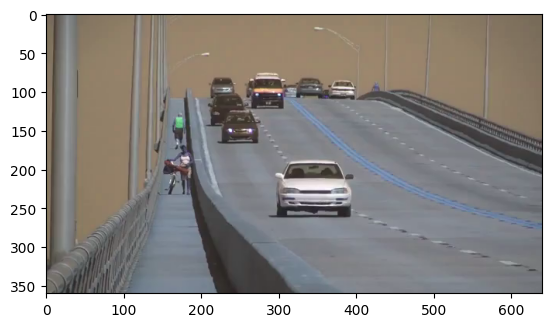

In [ ]:
plt.imshow(f)

In [ ]:
r,f=cap.read()

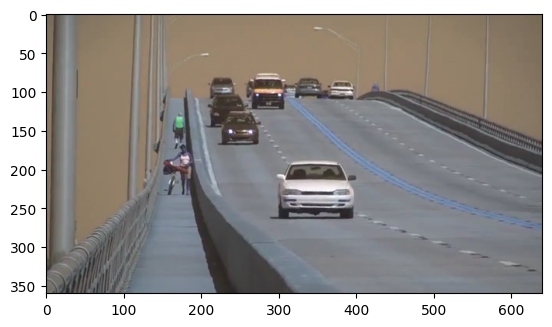

In [ ]:
plt.imshow(f)

In [ ]:
f_matrix=[]
cap=cv2.VideoCapture("/content/slow_traffic_small.mp4")
count=0
while True:
  r,f=cap.read()
  if f is not None:
    f=cv2.resize(f,(150,150))
    f_matrix.append(f)
    count=count+1
  else:
    break

In [ ]:
print(count)

914


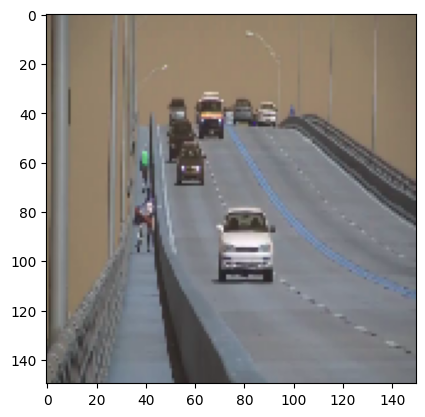

In [ ]:
plt.imshow(f_matrix[0])

In [ ]:
rw,cal,ch=f_matrix[0].shape
print(rw,cal,ch)

150 150 3


In [ ]:
f_matrix=np.array(f_matrix)

In [ ]:
B=np.zeros((rw,cal,ch))

In [ ]:
B.shape

(150, 150, 3)

In [ ]:
gmm=GaussianMixture(n_components=3)


In [ ]:
for r in range(rw):
  for c in range(cal):
    for k in range(ch):
      temp=f_matrix[0:15, r, c, k]
      ln=temp.shape[0]
      temp=temp.reshape(ln,1)
      gmm.fit(temp)
      means=gmm.means_
      weigths=gmm.weights_
      idx=np.argmax(weigths)
      pixel_value=means[idx][0]
      B[r][c][k]=int(pixel_value)



Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/

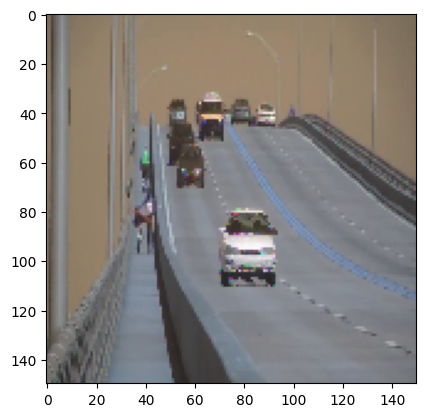

In [ ]:
Background=B
Background=Background/np.max(Background)
plt.imshow(Background)

In [ ]:
Background=rgb2gray(Background)
#50th frame
frame1=rgb2gray(f_matrix[50])
frame2=rgb2gray(f_matrix[250])
frame3=rgb2gray(f_matrix[500])
frame4=rgb2gray(f_matrix[750])

foreground1=frame1-Background
foreground2=frame2-Background
foreground3=frame3-Background
foreground4=frame4-Background

Text(0.5, 1.0, 'Foreground Frame 500')

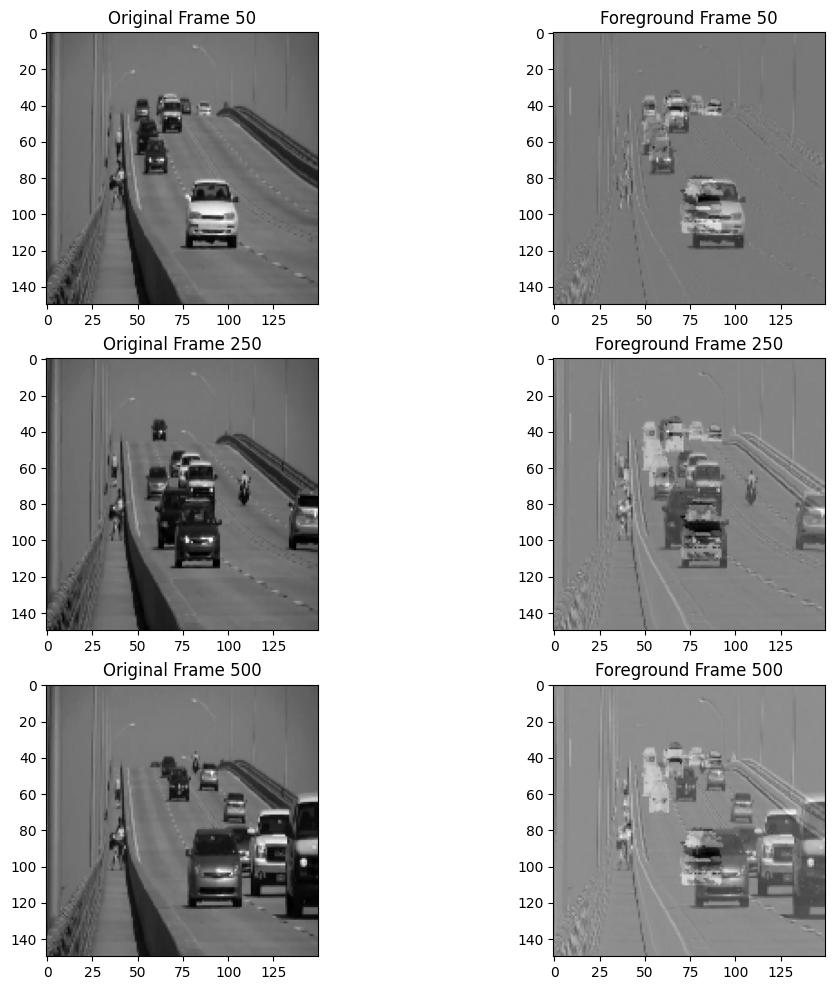

In [ ]:
plt.figure(figsize=(12,12))
plt.subplot(3,2,1)
plt.imshow(frame1,cmap="gray")
plt.title("Original Frame 50")

plt.subplot(3,2,2)
plt.imshow(foreground1,cmap="gray")
plt.title("Foreground Frame 50")

plt.subplot(3,2,3)
plt.imshow(frame2,cmap="gray")
plt.title("Original Frame 250")

plt.subplot(3,2,4)
plt.imshow(foreground2,cmap="gray")
plt.title("Foreground Frame 250")

plt.subplot(3,2,5)
plt.imshow(frame3,cmap="gray")
plt.title("Original Frame 500")

plt.subplot(3,2,6)
plt.imshow(foreground3,cmap="gray")
plt.title("Foreground Frame 500")




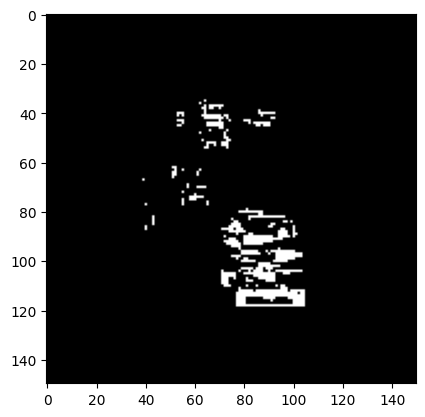

In [ ]:
foreground1=abs(frame1-Background)
foreground1[foreground1 > 0.3] = 250
foreground1[foreground1 <= 0.3] = 0
plt.imshow(foreground1,cmap="gray")

Conclusion: for the given video, first 15 frames are used to make the guassian filter model with K=3 with threshold of 0.2 for frames 50,250,500 show the cars which are moving with respect to cars in background image.  